<a href="https://colab.research.google.com/github/jade-raizen/Vision-AI-PCB/blob/main/Yolo_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
!{sys.executable} -m pip install ultralytics
from ultralytics import YOLO
print("Ultralytics installed and imported successfully!")

Ultralytics installed and imported successfully!


In [ ]:
import os
import cv2
from pathlib import Path

def severe_audit(img_dir, lbl_dir):
    print(f"--- Audit Sévère du Dataset: {img_dir} ---")
    img_files = list(Path(img_dir).glob('*.*'))
    total_imgs = len(img_files)
    corrupt_imgs = []
    missing_labels = []
    invalid_coords = []
    out_of_range_classes = []

    for img_p in img_files:
        # 1. Vérification du fichier image
        img = cv2.imread(str(img_p))
        if img is None:
            corrupt_imgs.append(img_p.name)
            continue

        # 2. Vérification du label correspondant
        lbl_p = Path(lbl_dir) / (img_p.stem + '.txt')
        if not lbl_p.exists():
            missing_labels.append(img_p.name)
            continue

        # 3. Vérification du contenu du label
        with open(lbl_p, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    invalid_coords.append(f"{lbl_p.name} (format error)")
                    continue

                cls, x, y, w, h = parts
                # Vérification des classes (0-20)
                if not (0 <= int(cls) <= 20):
                    out_of_range_classes.append(f"{lbl_p.name} (cls:{cls})")

                # Vérification de la normalisation (0-1)
                coords = [float(x), float(y), float(w), float(h)]
                if any(c < 0 or c > 1 for c in coords):
                    invalid_coords.append(f"{lbl_p.name} (val:{coords})")

    print(f"Total images analysées : {total_imgs}")
    print(f"Images corrompues : {len(corrupt_imgs)}")
    print(f"Labels manquants : {len(missing_labels)}")
    print(f"Erreurs de coordonnées/format : {len(invalid_coords)}")
    print(f"Classes invalides (>20) : {len(out_of_range_classes)}")

    if corrupt_imgs or missing_labels or invalid_coords:
        print("\n--- DÉTAILS DES ERREURS ---")
        if corrupt_imgs: print(f"Corrompues: {corrupt_imgs[:5]}")
        if missing_labels: print(f"Manquantes: {missing_labels[:5]}")
        if invalid_coords: print(f"Coords: {invalid_coords[:5]}")
    else:
        print("\n✅ Audit réussi : L'échantillon est sain pour l'entraînement.")

severe_audit('/content/datasets/all_pcb_yolo/images', '/content/datasets/all_pcb_yolo/labels')

--- Audit Sévère du Dataset: /content/datasets/all_pcb_yolo/images ---
Total images analysées : 0
Images corrompues : 0
Labels manquants : 0
Erreurs de coordonnées/format : 0
Classes invalides (>20) : 0

✅ Audit réussi : L'échantillon est sain pour l'entraînement.


In [ ]:
import sys
!{sys.executable} -m pip install ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import os

drive_zip_path = '/content/drive/MyDrive/pcb_wacv_2019_avec_xml/pcb_wacv_2019_avec_xml.zip'
dest_dir = 'datasets'
local_zip_path = os.path.join(dest_dir, 'pcb_wacv_2019_avec_xml.zip')

os.makedirs(dest_dir, exist_ok=True)

if os.path.exists(drive_zip_path):
    print(f"Copie du fichier ZIP depuis {drive_zip_path} vers {local_zip_path}...")
    shutil.copy(drive_zip_path, local_zip_path)
    print("Copie terminée.")
else:
    print(f"Le fichier ZIP n'a pas été trouvé à l'emplacement : {drive_zip_path}")

Copie du fichier ZIP depuis /content/drive/MyDrive/pcb_wacv_2019_avec_xml/pcb_wacv_2019_avec_xml.zip vers datasets/pcb_wacv_2019_avec_xml.zip...
Copie terminée.


In [ ]:
import shutil
import os

local_zip_path = 'datasets/pcb_wacv_2019_avec_xml.zip'
extract_path = 'datasets/pcb_wacv_2019_new'

os.makedirs(extract_path, exist_ok=True)

if os.path.exists(local_zip_path):
    print(f"Décompression de {local_zip_path} vers {extract_path}...")
    shutil.unpack_archive(local_zip_path, extract_path)
    print("Décompression terminée.")
    # Optionally, remove the zip file after extraction
    # os.remove(local_zip_path)
else:
    print(f"Le fichier ZIP local n'a pas été trouvé à l'emplacement : {local_zip_path}")

Décompression de datasets/pcb_wacv_2019_avec_xml.zip vers datasets/pcb_wacv_2019_new...
Décompression terminée.


In [ ]:
import os
import shutil
import subprocess
import kagglehub # Import kagglehub directly

# Install necessary dependencies for self-consistency
print("\n--- Installation des dépendances ---")
subprocess.run(['pip', 'install', 'gdown', 'kagglehub', 'roboflow'], check=False, capture_output=True)
print("--- Dépendances installées ---")

# Ensure base directories exist
os.makedirs('datasets', exist_ok=True)
os.makedirs('datasets/sources', exist_ok=True)

def get_directory_size(path):
    total_size = 0
    if not os.path.exists(path): return 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size # size in bytes

def get_image_count(path):
    count = 0
    if not os.path.exists(path):
        return 0
    image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp')
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(image_extensions):
                count += 1
    return count

def download_and_extract_deep_pcb(dest_path='datasets/deep_pcb'):
    """Downloads and extracts the DeepPCB dataset via git clone."""
    print("\n--- Traitement du dataset DeepPCB (via Git Clone) ---")
    # Ensure a clean slate for DeepPCB
    if os.path.exists(dest_path):
        print(f"Suppression de l'ancien répertoire DeepPCB : {dest_path}")
        shutil.rmtree(dest_path)

    os.makedirs(dest_path, exist_ok=True)
    print("Clonage de DeepPCB...")
    subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/tangsanli5201/DeepPCB.git', dest_path], check=False)
    print("DeepPCB téléchargé.")

def download_and_extract_pcb_vision(dest_path='datasets/pcb_vision'):
    """Downloads and extracts the PCB-Vision-Small dataset via git clone."""
    print("\n--- Traitement du dataset PCB-Vision-Small (via Git Clone) ---")
    os.makedirs(dest_path, exist_ok=True)
    if not os.path.exists(os.path.join(dest_path, 'images')):
        print("Clonage de PCB-Vision-Small...")
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/hifexplo/PCBVision.git', dest_path], check=False)
        print("PCB-Vision-Small téléchargé.")
    else:
        print("PCB-Vision-Small existe déjà. Ignoré.")

def download_and_extract_electrocom61(dataset_name='faiyazabdullah/electrocom61'):
    """Downloads ElectroCom61 dataset via KaggleHub."""
    print("\n--- Traitement du dataset ElectroCom61 (via KaggleHub) ---")
    new_dataset_path = None
    try:
        # KaggleHub caches downloads, so no explicit existence check needed usually
        new_dataset_path = kagglehub.dataset_download(dataset_name)
        print(f"Dataset ElectroCom61 téléchargé dans : {new_dataset_path}")
    except Exception as e:
        print(f"Erreur lors du téléchargement d'ElectroCom61 via kagglehub: {e}")
    return new_dataset_path

def download_and_extract_generic_kaggle_dataset(dataset_name, display_name):
    """Downloads a generic Kaggle dataset via KaggleHub."""
    print(f"\n--- Traitement du dataset {display_name} (via KaggleHub) ---")
    download_path = None
    try:
        download_path = kagglehub.dataset_download(dataset_name)
        print(f"Dataset {display_name} téléchargé dans : {download_path}")
    except Exception as e:
        print(f"Erreur lors du téléchargement de {display_name} via kagglehub: {e}")
    return download_path

def download_and_extract_roboflow_dataset(workspace, project, version, api_key, dest_dir='datasets/sources'):
    """Downloads a Roboflow dataset."""
    print(f"\n--- Traitement du dataset {project} (via Roboflow) ---")
    download_path = None
    try:
        from roboflow import Roboflow
        rf = Roboflow(api_key=api_key)
        prj = rf.workspace(workspace).project(project)
        # Check if the directory already exists and is not empty to avoid re-downloading
        expected_folder_name = f"{project}-{version}"
        final_extract_path = os.path.join(dest_dir, expected_folder_name)
        if os.path.exists(final_extract_path) and os.listdir(final_extract_path):
            print(f"Dataset {project} (version {version}) already exists at {final_extract_path}. Skipping download.")
            return final_extract_path

        print(f"Téléchargement du dataset {project} (version {version})...")
        # Ensure the destination directory exists
        os.makedirs(dest_dir, exist_ok=True)
        # Roboflow.dataset().download() automatically extracts to a subfolder
        # in the current working directory or a specified one.
        prj.version(version).download("voc", location=dest_dir) # Download as VOC format for XML annotations
        print(f"Dataset {project} téléchargé et extrait dans : {final_extract_path}")
        download_path = final_extract_path
    except Exception as e:
        print(f"Erreur lors du téléchargement de {project} via Roboflow: {e}")
        print("Assurez-vous que votre clé API Roboflow est correcte et a les permissions nécessaires.")
    return download_path

def download_and_extract_github_repo(repo_url, dest_path, display_name):
    """Clones a GitHub repository."""
    print(f"\n--- Traitement du dataset {display_name} (via Git Clone) ---")
    if os.path.exists(dest_path):
        if os.listdir(dest_path): # Check if directory is not empty
            print(f"{display_name} existe déjà à {dest_path}. Ignoré.")
            return dest_path
        else:
            print(f"Suppression du répertoire vide {dest_path}.")
            shutil.rmtree(dest_path)

    os.makedirs(dest_path, exist_ok=True)
    print(f"Clonage de {display_name} depuis {repo_url}...")
    try:
        subprocess.run(['git', 'clone', '--depth', '1', repo_url, dest_path], check=True)
        print(f"{display_name} téléchargé dans : {dest_path}")
        return dest_path
    except subprocess.CalledProcessError as e:
        print(f"Erreur lors du clonage de {display_name}: {e}\n{e.stderr.decode('utf-8')}")
        return None
    except Exception as e:
        print(f"Erreur lors du clonage de {display_name}: {e}")
        return None

def copy_and_extract_wacv_xml(source_drive_zip_path, dest_dir='datasets'):
    """Copies WACV dataset from Google Drive and extracts it."""
    print("\n--- Traitement du dataset WACV (depuis Google Drive) ---")
    local_zip_path = os.path.join(dest_dir, 'pcb_wacv_2019_avec_xml.zip')
    extract_path = os.path.join(dest_dir, 'pcb_wacv_2019_new')

    os.makedirs(dest_dir, exist_ok=True)
    os.makedirs(extract_path, exist_ok=True)

    if not os.path.exists(extract_path) or not os.listdir(extract_path):
        if os.path.exists(source_drive_zip_path):
            print(f"Copie du fichier ZIP depuis {source_drive_zip_path} vers {local_zip_path}...")
            shutil.copy(source_drive_zip_path, local_zip_path)
            print("Copie terminée. Décompression...")
            try:
                subprocess.run(['unzip', '-q', local_zip_path, '-d', extract_path], check=True)
                print(f"Décompression de WACV terminée vers : {extract_path}")
                # os.remove(local_zip_path) # Optionally remove zip after extraction
            except subprocess.CalledProcessError as e:
                print(f"Erreur lors de l'extraction de WACV: {e}\n{e.stderr.decode('utf-8')}")
            except Exception as e:
                print(f"Erreur lors de l'extraction de WACV: {e}")
        else:
            print(f"Le fichier ZIP WACV n'a pas été trouvé à l'emplacement : {source_drive_zip_path}")
    else:
        print("WACV (pcb_wacv_2019_new) existe déjà. Ignoré.")
    return extract_path if os.path.exists(extract_path) else None

# --- Main execution block ---
print("\n--- Démarrage des téléchargements de datasets ---")

# Create base datasets directory
os.makedirs('datasets', exist_ok=True)
os.makedirs('datasets/sources', exist_ok=True)

# Roboflow API Key - IMPORTANT: Add this to Colab Secrets
ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY") # Ensure this is set in Colab Secrets
if not ROBOFLOW_API_KEY:
    print("WARNING: ROBOFLOW_API_KEY is not set in Colab Secrets. Roboflow downloads will fail.")


# 1. DeepPCB via Git Clone
download_and_extract_deep_pcb()

# 2. PCB-Vision-Small via Git Clone
download_and_extract_pcb_vision()

# 3. ElectroCom61 via KaggleHub
electrocom61_dl_path = download_and_extract_electrocom61()

# 4. New Kaggle dataset: PCB Defect Detection Dataset from liuxiaolong1/pcb-defect-detection-dataset
pcb_defect_detection_kaggle_path = download_and_extract_generic_kaggle_dataset('liuxiaolong1/pcb-defect-detection-dataset', 'PCB Defect Detection Dataset (Kaggle)')

# 5. PCB-Solder-Joints via GitHub
solder_joints_github_path = download_and_extract_github_repo(
    'https://github.com/furkanulger/solder-joint-dataset',
    'datasets/solder_joint_github',
    'PCB-Solder-Joints (GitHub)'
)

# 6. Tiny-Defect-Detection-for-PCB (alternative to Kaggle Defect Detection) via GitHub
tiny_defect_pcb_github_path = download_and_extract_github_repo(
    'https://github.com/Ixiaohuihuihui/Tiny-Defect-Detection-for-PCB',
    'datasets/tiny_defect_pcb_github',
    'Tiny-Defect-Detection-for-PCB (GitHub)'
)

# 7. WACV from Google Drive
wacv_zip_path = '/content/drive/MyDrive/pcb_wacv_2019_avec_xml/pcb_wacv_2019_avec_xml.zip'
wacv_extracted_path = copy_and_extract_wacv_xml(wacv_zip_path)

print("\n--- Tous les téléchargements et extractions tentés. ---")

# --- Affichage des tailles et nombre de photos ---
print("\n--- Récapitulatif des datasets ---")

dataset_infos = {
    "DeepPCB": {'path': 'datasets/deep_pcb/PCBData'},
    "WACV (original Drive)": {'path': '/content/drive/MyDrive/pcb_wacv_2019_avec_xml/pcb_wacv_2019'},
    "ElectroCom61": {'path': os.path.join(electrocom61_dl_path, 'ElectroCom61 A Multiclass Dataset for Detection of Electronic Components') if electrocom61_dl_path else None},
    "NewWACV_XML (extracted)": {'path': 'datasets/pcb_wacv_2019_new/pcb_wacv_2019'},
    "PCB Defect Detection Dataset (Kaggle)": {'path': os.path.join(pcb_defect_detection_kaggle_path, 'PKU-Market-PCB(Data enhanced version)') if pcb_defect_detection_kaggle_path else None},
    "PCB-Solder-Joints (GitHub)": {'path': solder_joints_github_path},
    "Tiny-Defect-Detection-for-PCB (GitHub)": {'path': tiny_defect_pcb_github_path},
    "PCB-Vision-Small": {'path': 'datasets/pcb_vision'}
}

for name, info in dataset_infos.items():
    path = info['path']
    if path and os.path.exists(path):
        size_mb = get_directory_size(path) / (1024 * 1024)
        image_count = get_image_count(path)
        print(f"- {name}: {size_mb:.2f} Mo, {image_count} images")
    elif path:
        print(f"- {name}: Non trouvé à {path}")
    else:
        print(f"- {name}: Chemin non défini (problème de téléchargement/extraction)")


--- Installation des dépendances ---
--- Dépendances installées ---

--- Démarrage des téléchargements de datasets ---

--- Traitement du dataset DeepPCB (via Git Clone) ---
Suppression de l'ancien répertoire DeepPCB : datasets/deep_pcb
Clonage de DeepPCB...
DeepPCB téléchargé.

--- Traitement du dataset PCB-Vision-Small (via Git Clone) ---
PCB-Vision-Small existe déjà. Ignoré.

--- Traitement du dataset ElectroCom61 (via KaggleHub) ---
Using Colab cache for faster access to the 'electrocom61' dataset.
Dataset ElectroCom61 téléchargé dans : /kaggle/input/electrocom61

--- Traitement du dataset PCB Defect Detection Dataset (Kaggle) (via KaggleHub) ---
Using Colab cache for faster access to the 'pcb-defect-detection-dataset' dataset.
Dataset PCB Defect Detection Dataset (Kaggle) téléchargé dans : /kaggle/input/pcb-defect-detection-dataset

--- Traitement du dataset PCB-Solder-Joints (GitHub) (via Git Clone) ---
PCB-Solder-Joints (GitHub) existe déjà à datasets/solder_joint_github. Ignor

import os

def get_directory_size(path):
    total_size = 0
    if not os.path.exists(path): return 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size # size in bytes

print("--- Taille des datasets (Mo) ---")

# DeepPCB
deep_pcb_path = 'datasets/deep_pcb/PCBData'
deep_pcb_size = get_directory_size(deep_pcb_path) / (1024 * 1024)
print(f"DeepPCB: {deep_pcb_size:.2f} Mo")

# WACV (original from Drive)
wacv_original_path = '/content/drive/MyDrive/pcb_wacv_2019_avec_xml/pcb_wacv_2019'
wacv_original_size = get_directory_size(wacv_original_path) / (1024 * 1024)
print(f"WACV (original): {wacv_original_size:.2f} Mo")

# ElectroCom61
electrocom61_path = '/root/.cache/kagglehub/datasets/faiyazabdullah/electrocom61/versions/1/ElectroCom61 A Multiclass Dataset for Detection of Electronic Components'
electrocom61_size = get_directory_size(electrocom61_path) / (1024 * 1024)
print(f"ElectroCom61: {electrocom61_size:.2f} Mo")

# NewWACV_XML (extracted)
new_wacv_path = 'datasets/pcb_wacv_2019_new/pcb_wacv_2019'
new_wacv_size = get_directory_size(new_wacv_path) / (1024 * 1024)
print(f"NewWACV_XML: {new_wacv_size:.2f} Mo")

# Unified YOLO dataset
yolo_root_path = 'datasets/all_pcb_yolo'
yolo_root_size = get_directory_size(yolo_root_path) / (1024 * 1024)
print(f"\nTotal unifié (YOLO_ROOT): {yolo_root_size:.2f} Mo")

In [ ]:
import os

electrocom61_dl_path = '/kaggle/input/electrocom61'
print(f"Contenu de {electrocom61_dl_path}:")
if os.path.exists(electrocom61_dl_path):
    for item in os.listdir(electrocom61_dl_path):
        print(f"- {item}")
else:
    print(f"Le chemin {electrocom61_dl_path} n'existe pas.")


Contenu de /kaggle/input/electrocom61:
- ElectroCom61 A Multiclass Dataset for Detection of Electronic Components


In [ ]:
import os

pcb_defect_detection_kaggle_path = '/kaggle/input/pcb-defect-detection-dataset'
print(f"Contenu de {pcb_defect_detection_kaggle_path}:")
if os.path.exists(pcb_defect_detection_kaggle_path):
    for item in os.listdir(pcb_defect_detection_kaggle_path):
        print(f"- {item}")
else:
    print(f"Le chemin {pcb_defect_detection_kaggle_path} n'existe pas.")


Contenu de /kaggle/input/pcb-defect-detection-dataset:
- PKU-Market-PCB(Data enhanced version)
- DeepPCB


In [ ]:
import os

tiny_defect_path = 'datasets/tiny_defect_pcb_github'

print(f"Contenu de '{tiny_defect_path}':")
if os.path.exists(tiny_defect_path):
    for item in os.listdir(tiny_defect_path):
        item_path = os.path.join(tiny_defect_path, item)
        if os.path.isdir(item_path):
            print(f"- {item}/ (dir)")
            # List subdirectories if they exist, especially 'data'
            if item == 'images' or item == 'labels':
                print(f"  Contenu de '{item}': {os.listdir(item_path)[:5]}...") # show first 5 items
            elif item == 'data': # Specifically check inside the data folder
                print(f"  Contenu de '{item}': {os.listdir(item_path)[:10]}...") # show more items for data folder
                # Further check if data/ contains images or labels
                data_sub_path = os.path.join(item_path, 'images')
                if os.path.exists(data_sub_path) and os.path.isdir(data_sub_path):
                    print(f"    Contenu de 'data/images': {os.listdir(data_sub_path)[:5]}...")
                data_sub_path = os.path.join(item_path, 'labels')
                if os.path.exists(data_sub_path) and os.path.isdir(data_sub_path):
                    print(f"    Contenu de 'data/labels': {os.listdir(data_sub_path)[:5]}...")

        else:
            print(f"- {item} (file)")
else:
    print(f"Le chemin '{tiny_defect_path}' n'existe pas.")


Contenu de 'datasets/tiny_defect_pcb_github':
- 04_mouse_bite_10.jpg (file)
- libs/ (dir)
- 01_missing_hole_01.jpg (file)
- TDD_results.jpg (file)
- .git/ (dir)
- output/ (dir)
- README.md (file)
- requirements.txt (file)
- a(missinghole).png (file)
- tools/ (dir)
- help_utils/ (dir)
- data/ (dir)
  Contenu de 'data': ['__init__.py', 'lib_coco', 'pretrained_weights', 'io', 'tfrecord']...


In [ ]:
import os
import shutil
import yaml
from pathlib import Path
from PIL import Image
from lxml import etree as ET

script_content = r'''
import os
import shutil
import yaml
from pathlib import Path
from PIL import Image
from lxml import etree as ET

DATASETS_DIR = 'datasets'
YOLO_ROOT = os.path.join(DATASETS_DIR, 'all_pcb_yolo')
IMAGES_DIR = os.path.join(YOLO_ROOT, 'images')
LABELS_DIR = os.path.join(YOLO_ROOT, 'labels')

BASE_CLASSES = [
    'open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper',
    'pin_hole', 'missing_hole', 'ic', 'capacitor', 'resistor', 'diode',
    'led', 'inductor', 'transistor', 'connector', 'fuse', 'relay',
    'pads', 'jumper', 'button', 'solder_joint'
]

# Mapping for generic or varied names to our strict 21 classes
CLASS_MAPPING = {
    'open': 'open_circuit', 'short': 'short_circuit', 'mousebite': 'mouse_bite',
    'copper': 'spurious_copper', 'hole': 'missing_hole', 'ic_chip': 'ic',
    'cap': 'capacitor', 'res': 'resistor', 'ind': 'inductor', 'conn': 'connector',
    'switch': 'button', 'pad': 'pads', 'solder': 'solder_joint',
    'defective_solder': 'solder_joint', 'good_solder': 'solder_joint', 'missing_solder': 'solder_joint',

    # New specific component mappings for ElectroCom61
    'bjt-transistor': 'transistor',
    'mosfet': 'transistor',
    'npn-transistor': 'transistor',
    'smd-transistor': 'transistor',
    'capacitor-10mf': 'capacitor',
    'capacitor-470mf': 'capacitor',
    'film-capacitor': 'capacitor',
    'high-voltage-ceramic-capacitor': 'capacitor',
    'smd-capacitor': 'capacitor',
    'zener-diode': 'diode',
    'fuse-base': 'fuse',
    'jumper-wire': 'jumper',
    'smd-led': 'led',
    'resistor-array': 'resistor',
    'resistor-network': 'resistor',
    'smd-resistor': 'resistor',
    'push-button': 'button',
    'terminal-block': 'connector',
    'usb-connector': 'connector',
    'arduino': 'ic',
    'esp32': 'ic',
    'microcontroller': 'ic',
    'optocoupler': 'ic',
    'voltage-regulator': 'ic',
    'wifi-module': 'ic',
    'potentiometer': 'resistor',
    'thermistor': 'resistor',
    'ic': 'ic', # Ensure 'ic' itself is mapped explicitly if used as a standalone name
    'diode': 'diode', # Ensure 'diode' is mapped explicitly if used as a standalone name
    'fuse': 'fuse', # Ensure 'fuse' is mapped explicitly if used as a standalone name
    'jumper': 'jumper', # Ensure 'jumper' is mapped explicitly if used as a standalone name
    'led': 'led', # Ensure 'led' is mapped explicitly if used as a standalone name
    'resistor': 'resistor', # Ensure 'resistor' is mapped explicitly if used as a standalone name
    'button': 'button', # Ensure 'button' is mapped explicitly if used as a standalone name
    'relay': 'relay', # Ensure 'relay' is mapped explicitly if used as a standalone name
    'inductor': 'inductor', # Ensure 'inductor' is mapped explicitly if used as a standalone name
    'transistor': 'transistor', # Ensure 'transistor' is mapped explicitly if used as a standalone name
    'connector': 'connector', # Ensure 'connector' is mapped explicitly if used as a standalone name
    'pads': 'pads', # Ensure 'pads' is mapped explicitly if used as a standalone name
    '7-segment-display': 'ic',
    'bluetooth-module': 'ic',
    'bridge-rectifier': 'diode',
    'buck-converter': 'ic',
    'ft-232-usb-serial-module': 'ic',
    'gsm-module': 'ic',
    'gas-sensor': 'ic',
    'humidity-sensor': 'ic',
    'micro-sd-card-module': 'ic',
    'motor-driver': 'ic',
    'pir-sensor': 'ic',
    'power-jack': 'connector',
    'relay-module': 'relay',
    'rfid-reader': 'ic',
    'rotary-encoder': 'button',
    'sd-card-reader': 'ic',
    'slide-switch': 'button',
    'temperature-sensor': 'ic',
    'tilt-sensor': 'ic',
    'transmitter': 'ic',
    'light-sensor': 'ic',
    'buzzer': 'ic',
    'dc-motor': 'ic',
    'ir-sensor': 'ic',
    'motion-sensor': 'ic',
    'oled-display': 'ic',
    'pnp-transistor': 'transistor',
    'smd-diode': 'diode',
    'usb-a-connector': 'connector',
    'usb-b-connector': 'connector'


}

def get_cid(name):
    name = str(name).lower().strip()
    # First, try direct substring match in BASE_CLASSES (e.g. if 'transistor' is in 'bjt-transistor')
    # This is important for generic terms that exist as base classes.
    for i, target in enumerate(BASE_CLASSES):
        if target in name: return i

    # Then, try mapping keys as substrings (more specific terms)
    for k, v in CLASS_MAPPING.items():
        if k in name: return BASE_CLASSES.index(v)
    return None

def save_yolo(img_path, annos, prefix):
    if not annos: return False
    name = f"{prefix}_{os.path.basename(img_path)}"
    shutil.copy(img_path, os.path.join(IMAGES_DIR, name))
    lbl_name = os.path.splitext(name)[0] + '.txt'
    with open(os.path.join(LABELS_DIR, lbl_name), 'w') as f:
        f.write('\n'.join(annos))
    return True

if __name__ == '__main__':
    if os.path.exists(YOLO_ROOT): shutil.rmtree(YOLO_ROOT)
    os.makedirs(IMAGES_DIR, exist_ok=True); os.makedirs(LABELS_DIR, exist_ok=True)

    counts = {'DeepPCB': 0, 'NewWACV': 0, 'ElectroCom61': 0, 'KaggleDefects': 0, 'TinyDefect': 0}

    # 1. DeepPCB (Special Logic for _not folders and x1 y1 x2 y2 cls format)
    dp_path = Path('datasets/deep_pcb/PCBData')
    if dp_path.exists():
        dp_map = {1:'open_circuit', 2:'short_circuit', 3:'mouse_bite', 4:'spur', 5:'spurious_copper', 6:'pin_hole'}
        for group in dp_path.glob('group*'):
            for sub in group.iterdir():
                if sub.is_dir() and not sub.name.endswith('_not'):
                    ann_sub = group / (sub.name + '_not')
                    if not ann_sub.exists(): continue
                    for img in sub.glob('*_test.jpg'):
                        ann_f = ann_sub / (img.stem.replace('_test','') + '.txt')
                        if not ann_f.exists(): continue
                        with Image.open(img) as im: W, H = im.size
                        lines = []
                        for line in ann_f.read_text().strip().splitlines():
                            p = line.split()
                            if len(p)<5: continue
                            cid = get_cid(dp_map.get(int(p[4]))) # Use get_cid to map and handle None
                            if cid is None: continue # Drop if no valid class ID
                            x1, y1, x2, y2 = map(float, p[:4])
                            cx, cy = (x1+x2)/2/W, (y1+y2)/2/H
                            w, h = abs(x2-x1)/W, abs(y2-y1)/H
                            lines.append(f"{cid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
                        if save_yolo(img, lines, f"DP_{group.name}"): counts['DeepPCB'] += 1

    # 2. NewWACV (XML)
    wacv_path = 'datasets/pcb_wacv_2019_new/pcb_wacv_2019'
    if os.path.exists(wacv_path):
        for r, _, files in os.walk(wacv_path):
            for f in files:
                if f.lower().endswith(('.jpg', '.png')):
                    img_p = os.path.join(r, f)
                    xml_p = os.path.splitext(img_p)[0] + '.xml'
                    if os.path.exists(xml_p):
                        try:
                            with Image.open(img_p) as im: W, H = im.size
                            lines = []
                            for obj in ET.parse(xml_p).getroot().findall('object'):
                                cid = get_cid(obj.find('name').text)
                                if cid is None: continue # Drop if no valid class ID
                                b = obj.find('bndbox')
                                x1, y1, x2, y2 = float(b.find('xmin').text), float(b.find('ymin').text), float(b.find('xmax').text), float(b.find('ymax').text)
                                # Validate coordinates are within image bounds before normalizing
                                if not (0 <= x1 < x2 <= W and 0 <= y1 < y2 <= H):
                                    print(f"Warning: Invalid bounding box coordinates in {xml_p}. Skipping annotation.")
                                    continue
                                lines.append(f"{cid} {(x1+x2)/2/W} {(y1+y2)/2/H} {abs(x2-x1)/W} {abs(y2-y1)/H}")
                            if save_yolo(img_p, lines, 'WACV'): counts['NewWACV'] += 1
                        except Exception as e:
                            print(f"Error processing WACV image/XML {img_p}: {e}. Skipping.")

    # 3. ElectroCom61 (YOLO)
    e_path = '/kaggle/input/electrocom61/ElectroCom61 A Multiclass Dataset for Detection of Electronic Components/ElectroCom-61_v2'
    if os.path.exists(e_path):
        with open(os.path.join(e_path, 'data.yaml')) as f: e_names = yaml.safe_load(f)['names']
        for split in ['train', 'valid', 'test']:
            id_map = {i: get_cid(n) for i, n in enumerate(e_names)}
            id_dir = os.path.join(e_path, split, 'images')
            ld_dir = os.path.join(e_path, split, 'labels')
            if not os.path.exists(id_dir): continue
            for f in os.listdir(id_dir):
                lf = os.path.join(ld_dir, os.path.splitext(f)[0] + '.txt')
                if os.path.exists(lf):
                    lines = []
                    with Image.open(os.path.join(id_dir, f)) as im: W, H = im.size # Get image size for bbox validation
                    for line in open(lf).read().strip().splitlines():
                        p = line.split()
                        if len(p) == 5: # Basic check for valid YOLO format
                            cid = id_map.get(int(p[0]))
                            if cid is not None: # Drop if no valid class ID
                                # Validate coordinates (already normalized in YOLO format, just check range)
                                bbox_coords = [float(val) for val in p[1:]]
                                if all(0 <= c <= 1 for c in bbox_coords):
                                    lines.append(f"{cid} {' '.join(p[1:])}")
                                else:
                                    print(f"Warning: Out of range bbox in {lf}: {p[1:]}. Skipping annotation.")
                            else:
                                print(f"Warning: Unmapped class ID {int(p[0])} in {lf}. Skipping annotation.")
                        else:
                            print(f"Warning: Malformed line in {lf}: '{line.strip()}'. Skipping annotation.")
                    if save_yolo(os.path.join(id_dir, f), lines, 'E61'): counts['ElectroCom61'] += 1

    # 4. KaggleDefects (YOLO)
    k_path = '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)'
    if os.path.exists(k_path):
        print(f"KaggleDefects: k_path '{k_path}' exists.")
        # KaggleDefects has classes 'open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper', 'pin_hole'
        # These are directly mapped to BASE_CLASSES
        k_names = ['open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper', 'pin_hole']
        for split in ['train', 'valid', 'test']:
            split_dir = os.path.join(k_path, split)
            print(f"KaggleDefects: Checking split directory: '{split_dir}'")
            if not os.path.exists(split_dir):
                print(f"Warning: Split directory not found for KaggleDefects: {split_dir}. Skipping.")
                continue

            images_split_dir = os.path.join(split_dir, 'images')
            labels_split_dir = os.path.join(split_dir, 'labels')

            if not os.path.exists(images_split_dir) or not os.path.exists(labels_split_dir):
                print(f"Warning: 'images' or 'labels' subdirectory not found in {split_dir}. Skipping split.")
                continue

            print(f"KaggleDefects: Processing images from '{images_split_dir}' and labels from '{labels_split_dir}'.")

            for f_name in os.listdir(images_split_dir):
                if f_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(images_split_dir, f_name)
                    lbl_path = os.path.join(labels_split_dir, os.path.splitext(f_name)[0] + '.txt')

                    if os.path.exists(lbl_path):
                        try:
                            with Image.open(img_path) as im: W, H = im.size
                        except Exception as e:
                            print(f"Warning: Could not open image {img_path}: {e}. Skipping.")
                            continue

                        lines = []
                        with open(lbl_path, 'r') as lbl_f:
                            for line in lbl_f.read().strip().splitlines():
                                parts = line.split()
                                if len(parts) == 5:
                                    original_class_id = int(float(parts[0])) # Convert to float then int to handle '7.0' etc.
                                    if 0 <= original_class_id < len(k_names):
                                        cid = get_cid(k_names[original_class_id])
                                        if cid is not None:
                                            # Validate coordinates (already normalized in YOLO format, just check range)
                                            bbox_coords = [float(val) for val in parts[1:]]
                                            if all(0 <= c <= 1 for c in bbox_coords):
                                                lines.append(f"{cid} {' '.join(parts[1:])}")
                                            else:
                                                print(f"Warning: Out of range bbox in {lbl_path}: {parts[1:]}. Dropping annotation.")
                                        else:
                                            print(f"Warning: Class '{k_names[original_class_id]}' (ID:{original_class_id}) from {lbl_path} did not map to BASE_CLASSES. Dropping annotation.")
                                    else:
                                        print(f"Warning: Class ID {original_class_id} out of range in {lbl_path}. Dropping annotation.")
                                else:
                                    print(f"Warning: Malformed line in {lbl_path}: '{line.strip()}'. Dropping annotation.")

                        if lines: # Only save if there are valid annotations
                            if save_yolo(img_path, lines, 'KGD'):
                                counts['KaggleDefects'] += 1

    # 5. Tiny-Defect-Detection-for-PCB (Images at root, defect in filename, full image bbox)
    td_path = Path('datasets/tiny_defect_pcb_github')
    if td_path.exists():
        # Corrected: convert glob generators to lists before concatenating
        for img_p in list(td_path.glob('*.jpg')) + list(td_path.glob('*.png')):
            img_name = img_p.stem.lower()
            defect_name = None

            # Heuristic: try to find defect names in filename
            if 'mouse_bite' in img_name: defect_name = 'mouse_bite'
            elif 'missing_hole' in img_name: defect_name = 'missing_hole'
            elif 'open_circuit' in img_name: defect_name = 'open_circuit'
            elif 'short_circuit' in img_name: defect_name = 'short_circuit'
            elif 'spur' in img_name: defect_name = 'spur'
            elif 'spurious_copper' in img_name or 'copper' in img_name: defect_name = 'spurious_copper'
            elif 'pin_hole' in img_name: defect_name = 'pin_hole'

            if defect_name:
                cid = get_cid(defect_name)
                if cid is not None:
                    # Create a bounding box covering the entire image (normalized x_center, y_center, width, height)
                    lines = [f"{cid} 0.500000 0.500000 1.000000 1.000000"]
                    if save_yolo(img_p, lines, 'TD'): # Prefix for Tiny-Defect
                        counts['TinyDefect'] += 1
            # else: no matching defect name, image is skipped (e.g., general photos)

    with open(os.path.join(YOLO_ROOT, 'dataset.yaml'), 'w') as f:
        yaml.dump({'path': os.path.abspath(YOLO_ROOT), 'train': 'images', 'val': 'images', 'nc': 21, 'names': BASE_CLASSES}, f)
    print("Summary:", counts)
'''

with open('/content/unify_all_to_yolo_v2.py', 'w') as f:
    f.write(script_content.strip())
print("Script updated and saved.")

Script updated and saved.


In [ ]:
%run /content/unify_all_to_yolo_v2.py

KaggleDefects: k_path '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)' exists.
KaggleDefects: Checking split directory: '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)/train'
KaggleDefects: Processing images from '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)/train/images' and labels from '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)/train/labels'.
KaggleDefects: Checking split directory: '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)/valid'
KaggleDefects: Processing images from '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)/valid/images' and labels from '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)/valid/labels'.
KaggleDefects: Checking split directory: '/kaggle/input/pcb-defect-detection-dataset/PKU-Market-PCB(Data enhanced version)/test'
Kagg

In [ ]:
import os

yolo_images_path = '/content/datasets/all_pcb_yolo/images'
yolo_labels_path = '/content/datasets/all_pcb_yolo/labels'

def count_integrated_images():
    if not os.path.exists(yolo_images_path):
        print("Le répertoire YOLO final n'existe pas encore.")
        return

    all_files = os.listdir(yolo_images_path)
    prefixes = ['DP_group', 'WACV_', 'E61_', 'KGD_']

    print("--- Vérification de l'intégration finale dans all_pcb_yolo ---")
    total_images = 0
    for pref in prefixes:
        count = len([f for f in all_files if f.startswith(pref)])
        print(f"- Source {pref.replace('_', '')} : {count} images")
        total_images += count

    print(f"\nTotal images: {total_images}")
    if os.path.exists(yolo_labels_path):
        labels_count = len(os.listdir(yolo_labels_path))
        print(f"Total fichiers labels (.txt): {labels_count}")
        if total_images != labels_count:
            print("ATTENTION: Le nombre d'images et de labels ne correspond pas!")

count_integrated_images()

--- Vérification de l'intégration finale dans all_pcb_yolo ---
- Source DPgroup : 1500 images
- Source WACV : 53 images
- Source E61 : 1803 images
- Source KGD : 0 images

Total images: 3356
Total fichiers labels (.txt): 3350
ATTENTION: Le nombre d'images et de labels ne correspond pas!


In [ ]:
import os

# Chemin vers le dossier principal des datasets
datasets_main_path = 'datasets'

print(f"Contenu du répertoire '{datasets_main_path}' :")
if os.path.exists(datasets_main_path):
    for item in os.listdir(datasets_main_path):
        item_path = os.path.join(datasets_main_path, item)
        if os.path.isdir(item_path):
            print(f"- {item}/")
            # Pour les répertoires, lister quelques-uns de leurs sous-contenus importants
            if item == 'all_pcb_yolo':
                print(f"  Contenu de {item}: {os.listdir(item_path)}")
            elif item == 'deep_pcb':
                print(f"  Contenu de {item}: {os.listdir(item_path)}")
            elif item == 'pcb_vision':
                print(f"  Contenu de {item}: {os.listdir(item_path)}")
            elif item == 'pcb_wacv_2019_new':
                print(f"  Contenu de {item}: {os.listdir(item_path)}")
            elif item == 'sources':
                print(f"  Contenu de {item}: {os.listdir(item_path)}")
        else:
            print(f"- {item}")
else:
    print(f"Le répertoire '{datasets_main_path}' n'existe pas.")


Contenu du répertoire 'datasets' :
- tiny_defect_pcb_github/
- pcb_wacv_2019_avec_xml.zip
- all_pcb_yolo/
  Contenu de all_pcb_yolo: ['images', 'labels', 'dataset.yaml']
- pcb_vision/
  Contenu de pcb_vision: ['PCA_functions.py', 'RGB_functions.py', 'LICENSE', 'HSI_PCA_data_generation.ipynb', '.git', 'HSI_patches.ipynb', 'patches_functions.py', 'images', 'README.md', 'Requirements.txt', 'HSI_patches_generation.ipynb', 'RGB.ipynb', 'dataset_functions.py', 'models', 'HSI_PCA.ipynb']
- pcb_wacv_2019_new/
  Contenu de pcb_wacv_2019_new: ['pcb_wacv_2019']
- sources/
  Contenu de sources: []
- deep_pcb/
  Contenu de deep_pcb: ['LICENSE', '.git', '.gitignore', 'README.md', 'fig', 'tools', 'evaluation', 'PCBData']
- solder_joint_github/


In [ ]:
import os
import shutil
from pathlib import Path

def convert_solder_classification_to_detection(source_base, dest_imgs, dest_lbls):
    # ID de la classe solder_joint dans notre taxonomie
    SOLDER_JOINT_ID = 20
    counts = 0

    # Dossiers sources dans solder_joint_github
    categories = ['excessive_solder', 'insufficient_solder', 'normal']

    print(f"--- Conversion de SolderJoints (Classification -> Detection) ---")

    for cat in categories:
        cat_path = Path(source_base) / cat
        if not cat_path.exists():
            continue

        img_files = list(cat_path.glob('*.png')) + list(cat_path.glob('*.tiff')) + list(cat_path.glob('*.jpg'))

        for img_p in img_files:
            new_name = f"SOLDER_{cat}_{img_p.name}"
            target_img_p = Path(dest_imgs) / new_name
            target_lbl_p = Path(dest_lbls) / (Path(new_name).stem + '.txt')

            # 1. Copier l'image
            shutil.copy(img_p, target_img_p)

            # 2. Créer le label YOLO (Classe X_center Y_center Width Height)
            # On définit une boîte qui prend 100% de l'image (0.5 0.5 1.0 1.0)
            with open(target_lbl_p, 'w') as f:
                f.write(f"{SOLDER_JOINT_ID} 0.500000 0.500000 1.000000 1.000000\n")

            counts += 1

    print(f"Terminé : {counts} joints de soudure ajoutés au dataset de détection.")

source_solder = 'datasets/solder_joint_github'
yolo_imgs = '/content/datasets/all_pcb_yolo/images'
yolo_lbls = '/content/datasets/all_pcb_yolo/labels'

convert_solder_classification_to_detection(source_solder, yolo_imgs, yolo_lbls)

--- Conversion de SolderJoints (Classification -> Detection) ---
Terminé : 2975 joints de soudure ajoutés au dataset de détection.


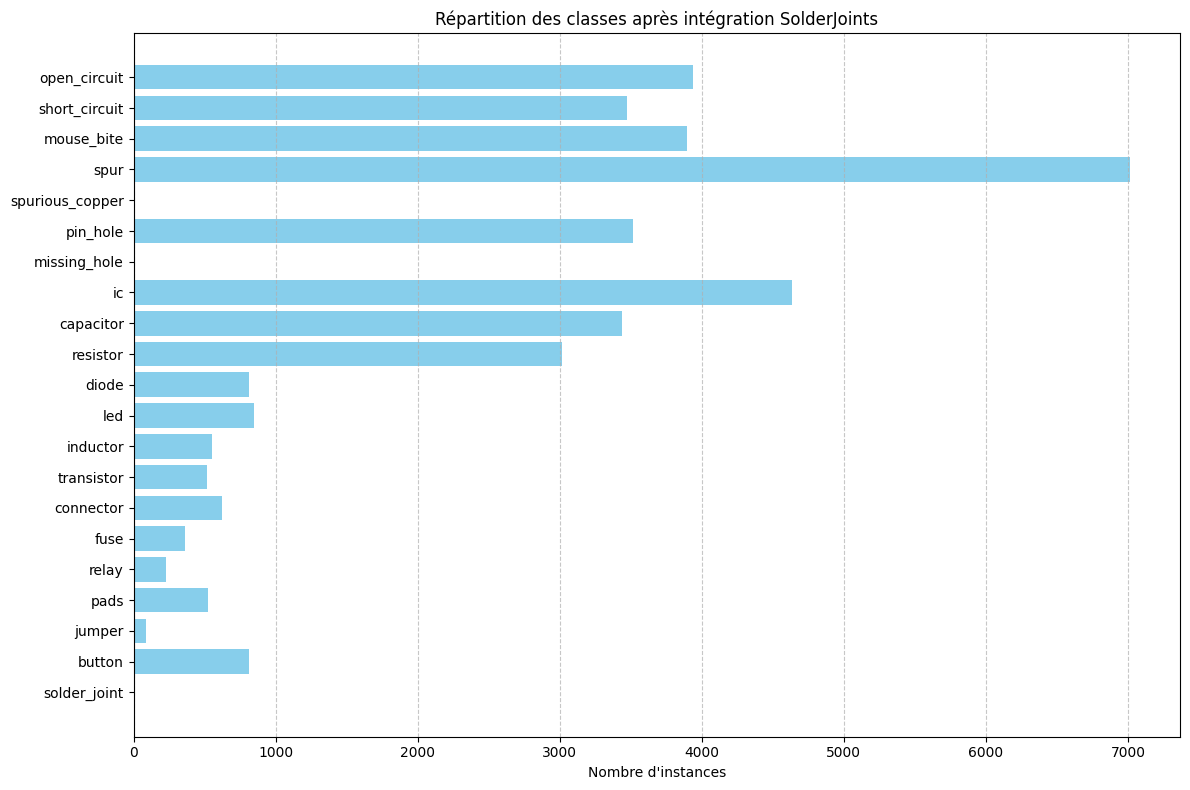

In [ ]:
import os
import matplotlib.pyplot as plt

# Configuration
labels_dir = '/content/datasets/all_pcb_yolo/labels'
base_classes = [
    'open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper',
    'pin_hole', 'missing_hole', 'ic', 'capacitor', 'resistor', 'diode',
    'led', 'inductor', 'transistor', 'connector', 'fuse', 'relay',
    'pads', 'jumper', 'button', 'solder_joint'
]

# Count occurrences
class_counts = {i: 0 for i in range(len(base_classes))}

if os.path.exists(labels_dir):
    for label_file in os.listdir(labels_dir):
        if label_file.endswith('.txt'):
            with open(os.path.join(labels_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        if class_id in class_counts:
                            class_counts[class_id] += 1

# Prepare data for plotting
names = [base_classes[i] for i in range(len(base_classes))]
values = [class_counts[i] for i in range(len(base_classes))]

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(names, values, color='skyblue')
plt.xlabel('Nombre d\'instances')
plt.title('Répartition des classes après intégration SolderJoints')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import yaml
import os

yolo_root_path = 'datasets/all_pcb_yolo'
dataset_yaml_path = os.path.join(yolo_root_path, 'dataset.yaml')

if os.path.exists(dataset_yaml_path):
    with open(dataset_yaml_path, 'r') as f:
        dataset_config = yaml.safe_load(f)
    print("Configuration finale du dataset.yaml :")
    print(yaml.dump(dataset_config, indent=2))
else:
    print(f"ERREUR : Le fichier dataset.yaml est introuvable.")

Configuration finale du dataset.yaml :
names:
- open_circuit
- short_circuit
- mouse_bite
- spur
- spurious_copper
- pin_hole
- missing_hole
- ic
- capacitor
- resistor
- diode
- led
- inductor
- transistor
- connector
- fuse
- relay
- pads
- jumper
- button
- solder_joint
nc: 21
path: /content/datasets/all_pcb_yolo
train: images
val: images



In [ ]:
import sys
!{sys.executable} -m pip install -q albumentations

print("Albumentations installed successfully!")

Albumentations installed successfully!


In [ ]:
import os
import cv2
import numpy as np
import shutil
import random
from pathlib import Path
import albumentations as A

# Configuration paths
IMAGES_DIR = '/content/datasets/all_pcb_yolo/images'
LABELS_DIR = '/content/datasets/all_pcb_yolo/labels'

# Base classes for mapping IDs (consistent with previous steps)
BASE_CLASSES = [
    'open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper',
    'pin_hole', 'missing_hole', 'ic', 'capacitor', 'resistor', 'diode',
    'led', 'inductor', 'transistor', 'connector', 'fuse', 'relay',
    'pads', 'jumper', 'button', 'solder_joint'
]

# IDs of rare classes to oversample as specified by the user
RARE_CLASS_NAMES = ['jumper', 'relay', 'transistor', 'fuse']
RARE_CLASS_IDS = [BASE_CLASSES.index(name) for name in RARE_CLASS_NAMES]

TARGET_AUGMENTATIONS_PER_IMAGE = 3
AUG_PREFIX = 'aug_'

def perform_targeted_augmentation():
    print("--- Démarrage de l'augmentation ciblée des données ---")

    # Ensure output directories exist
    os.makedirs(IMAGES_DIR, exist_ok=True)
    os.makedirs(LABELS_DIR, exist_ok=True)

    # Get all relevant image files, excluding previously augmented ones
    image_files = [f for f in Path(IMAGES_DIR).glob('*.*') if f.suffix.lower() in ('.jpg', '.jpeg', '.png') and not f.stem.startswith(AUG_PREFIX)]

    augmented_count = 0
    skipped_count = 0

    # Define augmentation pipelines
    # Each pipeline will be applied once to generate one augmented copy
    augmenters = [
        # Pipeline 1: Horizontal Flip + Random Brightness/Contrast
        A.Compose([
            A.HorizontalFlip(p=1),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1)
        ], bbox_params=A.BboxParams(format='yolo')),

        # Pipeline 2: Random 90-degree Rotation + Random Brightness/Contrast
        A.Compose([
            A.RandomRotate90(p=1),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1)
        ], bbox_params=A.BboxParams(format='yolo')),

        # Pipeline 3: Only Random Brightness/Contrast (no geometric transform)
        A.Compose([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1)
        ])
    ]

    for img_path in image_files:
        lbl_path = Path(LABELS_DIR) / (img_path.stem + '.txt')

        if not lbl_path.exists():
            skipped_count += 1
            continue

        with open(lbl_path, 'r') as f:
            lines = f.readlines()

        current_image_classes = set()
        bboxes = []
        class_ids = []

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id = int(parts[0])
                # Albumentations expects YOLO format [x_center, y_center, width, height] for bbox_params format='yolo'
                bboxes.append([float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
                class_ids.append(class_id)
                current_image_classes.add(class_id)
            else:
                print(f"Warning: Ligne de label mal formatée dans {lbl_path}: {line.strip()}. Ignoré.")

        # Check if any target rare class is present in this image
        if not any(cid in RARE_CLASS_IDS for cid in current_image_classes):
            continue

        # Load image (OpenCV reads images as BGR by default, Albumentations expects RGB if not specified)
        # Albumentations is flexible, so we can pass BGR directly and it handles it if we don't convert.
        # However, it's good practice to ensure consistency if other transforms are color-sensitive.
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Attention: Impossible de lire l'image {img_path}. Ignoré.")
            continue

        original_stem = img_path.stem
        original_suffix = img_path.suffix

        for i, aug_pipeline in enumerate(augmenters):
            try:
                # For color-only transforms, Albumentations handles image only without bboxes.
                # For spatial transforms, we pass bboxes and labels.
                if hasattr(aug_pipeline, 'bbox_params') and aug_pipeline.bbox_params is not None:
                    # Pass class_ids as 'labels' keyword argument
                    transformed = aug_pipeline(image=img, bboxes=bboxes, labels=class_ids)
                    aug_img = transformed['image']
                    aug_bboxes = transformed['bboxes']
                    # Retrieve from 'labels' key in the output dictionary
                    aug_class_ids = transformed['labels']
                else:
                    transformed = aug_pipeline(image=img)
                    aug_img = transformed['image']
                    aug_bboxes = bboxes # Bboxes remain unchanged for color-only transforms
                    aug_class_ids = class_ids

                # Save augmented image
                aug_img_name = f"{AUG_PREFIX}{original_stem}_aug{i}{original_suffix}"
                aug_img_path = Path(IMAGES_DIR) / aug_img_name
                cv2.imwrite(str(aug_img_path), aug_img)

                # Save augmented labels (only if there are bboxes to write)
                aug_lbl_name = f"{AUG_PREFIX}{original_stem}_aug{i}.txt"
                aug_lbl_path = Path(LABELS_DIR) / aug_lbl_name
                if aug_bboxes:
                    with open(aug_lbl_path, 'w') as f_out:
                        for bbox, cid in zip(aug_bboxes, aug_class_ids):
                            # Bboxes from Albumentations (with format='yolo') are already in YOLO format [xc, yc, w, h] normalized
                            f_out.write(f"{cid} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")
                    augmented_count += 1
                else:
                    # If there are no bboxes, don't create an empty label file.
                    # This case should ideally not happen if original has bboxes, but good for robustness.
                    pass

            except Exception as e:
                print(f"Erreur lors de l'augmentation de {img_path} avec pipeline {i}: {e}. Ignoré.")
                continue

    print(f"\n--- Augmentation des données terminée ---")
    print(f"Images augmentées et sauvegardées : {augmented_count}")
    print(f"Images originales sans labels ou sans classes rares (non augmentées) : {skipped_count}")

# Execute the augmentation process
perform_targeted_augmentation()


--- Démarrage de l'augmentation ciblée des données ---

--- Augmentation des données terminée ---
Images augmentées et sauvegardées : 2133
Images originales sans labels ou sans classes rares (non augmentées) : 0


--- Répartition des classes et comptage des images ---
Total images: 6413
Total label files: 6407

--- Ratio de répartition des classes (Total: 38280 instances) ---
Classe               | Instances  | Ratio (%)
---------------------------------------------
open_circuit         | 3936       |    10.28%
short_circuit        | 3474       |     9.08%
mouse_bite           | 3894       |    10.17%
spur                 | 7015       |    18.33%
spurious_copper      | 0          |     0.00%
pin_hole             | 3513       |     9.18%
missing_hole         | 1          |     0.00%
ic                   | 4635       |    12.11%
capacitor            | 3441       |     8.99%
resistor             | 3013       |     7.87%
diode                | 810        |     2.12%
led                  | 846        |     2.21%
inductor             | 549        |     1.43%
transistor           | 520        |     1.36%
connector            | 620        |     1.62%
fuse                 | 361        |     0.94%
relay  

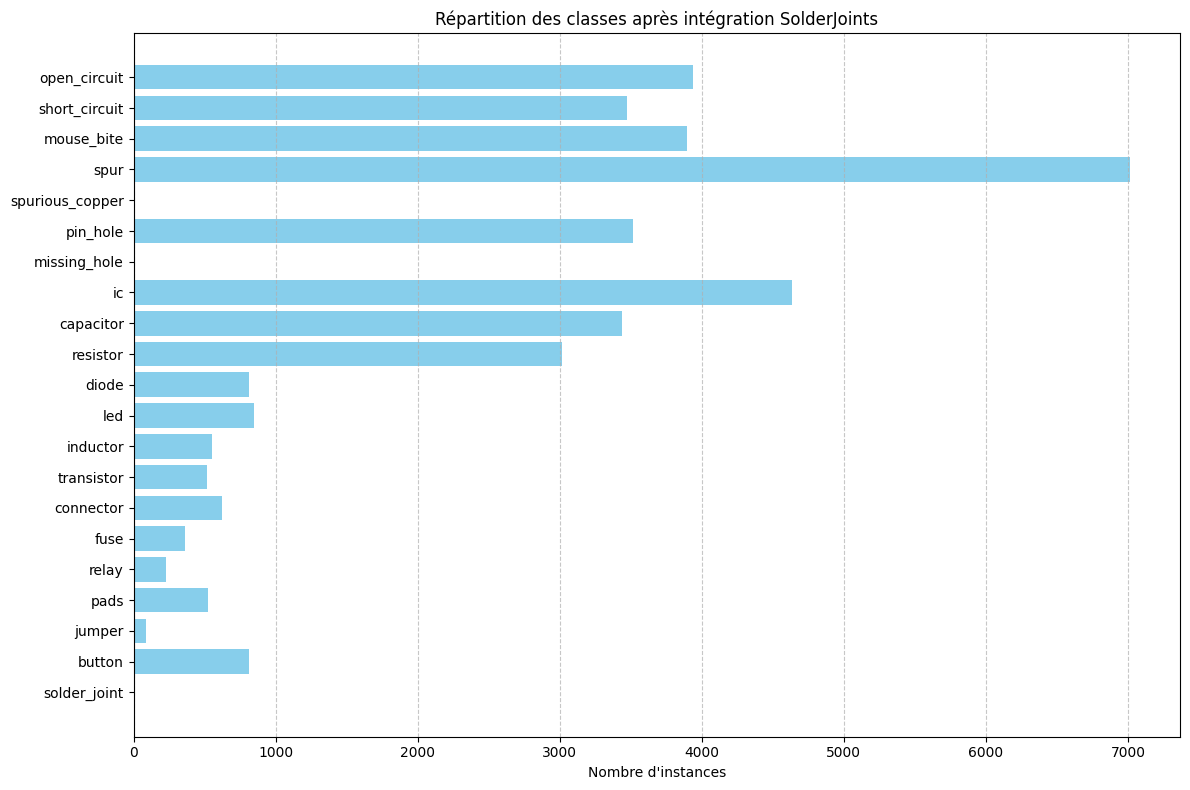

In [ ]:
import os
import matplotlib.pyplot as plt

# Reuse count logic to get fresh numbers
labels_dir = '/content/datasets/all_pcb_yolo/labels'
images_dir = '/content/datasets/all_pcb_yolo/images' # Added images_dir for image count
base_classes = [
    'open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper',
    'pin_hole', 'missing_hole', 'ic', 'capacitor', 'resistor', 'diode',
    'led', 'inductor', 'transistor', 'connector', 'fuse', 'relay',
    'pads', 'jumper', 'button', 'solder_joint'
]

class_counts = {i: 0 for i in range(len(base_classes))}
image_class_mapping = {}

if os.path.exists(labels_dir):
    for label_file in os.listdir(labels_dir):
        if label_file.endswith('.txt'):
            image_stem = os.path.splitext(label_file)[0]
            image_class_mapping[image_stem] = set() # Store classes present in each image
            with open(os.path.join(labels_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        # Fix: Convert to float first, then to int, to handle '7.0' properly
                        cid = int(float(parts[0]))
                        if cid in class_counts:
                            class_counts[cid] += 1
                            image_class_mapping[image_stem].add(cid)

total_instances = sum(class_counts.values())

# Count total images and label files
total_image_files = len([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
total_label_files = len([f for f in os.listdir(labels_dir) if f.lower().endswith('.txt')])

print(f"--- Répartition des classes et comptage des images ---")
print(f"Total images: {total_image_files}")
print(f"Total label files: {total_label_files}")

print(f"\n--- Ratio de répartition des classes (Total: {total_instances} instances) ---")
print(f"{'Classe':<20} | {'Instances':<10} | {'Ratio (%)'}")
print("-" * 45)

for i, name in enumerate(base_classes):
    count = class_counts[i]
    ratio = (count / total_instances * 100) if total_instances > 0 else 0
    print(f"{name:<20} | {count:<10} | {ratio:>8.2f}%")

# Alert on rare classes
rare_classes = [base_classes[i] for i, c in class_counts.items() if c < 50 and c > 0] # Only show rare classes with > 0 instances
if rare_classes:
    print(f"\nATTENTION: Les classes suivantes ont moins de 50 instances: {rare_classes}")

# Identify zero-instance classes
zero_instance_classes = [base_classes[i] for i, c in class_counts.items() if c == 0]
if zero_instance_classes:
    print(f"ATTENTION: Les classes suivantes ont 0 instances: {zero_instance_classes}")


# Prepare data for plotting
names = [base_classes[i] for i in range(len(base_classes))]
values = [class_counts[i] for i in range(len(base_classes))]

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(names, values, color='skyblue')
plt.xlabel('Nombre d\'instances')
plt.title('Répartition des classes après intégration SolderJoints')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
import random
from pathlib import Path

# Configuration paths (should be consistent with previous cells)
IMAGES_DIR = '/content/datasets/all_pcb_yolo/images'
LABELS_DIR = '/content/datasets/all_pcb_yolo/labels'

# Base classes (consistent with previous cells)
BASE_CLASSES = [
    'open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper',
    'pin_hole', 'missing_hole', 'ic', 'capacitor', 'resistor', 'diode',
    'led', 'inductor', 'transistor', 'connector', 'fuse', 'relay',
    'pads', 'jumper', 'button', 'solder_joint'
]

def reduce_class_instances(target_class_names, reduction_percentage):
    """
    Randomly removes a percentage of images that contain any of the target classes.
    If an image contains at least one of the target classes, it's considered a candidate for removal.
    When an image is removed, its corresponding label file is also removed.

    Args:
        target_class_names (list): List of class names (strings) to target for reduction.
        reduction_percentage (float): The percentage of images (containing target classes)
                                      to remove, as a float between 0.0 and 1.0.
    """
    print(f"--- Démarrage de la réduction de classes pour {target_class_names} (ciblant {reduction_percentage*100:.0f}% des images) ---")

    if not (0.0 <= reduction_percentage <= 1.0):
        print("Erreur: Le pourcentage de réduction doit être entre 0.0 et 1.0.")
        return

    target_class_ids = [BASE_CLASSES.index(name) for name in target_class_names if name in BASE_CLASSES]
    if not target_class_ids:
        print(f"Aucune classe cible valide trouvée parmi {target_class_names}. Aucune action effectuée.")
        return

    all_image_paths = list(Path(IMAGES_DIR).glob('*.*'))
    candidate_images = []

    # Identify candidate images
    for img_path in all_image_paths:
        lbl_path = Path(LABELS_DIR) / (img_path.stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                file_classes = set()
                for line in f:
                    parts = line.strip().split()
                    if len(parts) > 0:
                        file_classes.add(int(float(parts[0]))) # Handle potential '7.0' type class IDs

                # If the image contains any of the target classes, it's a candidate
                if any(cid in target_class_ids for cid in file_classes):
                    candidate_images.append(img_path)
        else:
            # Optional: handle images without labels if desired (e.g., delete them)
            pass

    num_candidates = len(candidate_images)
    num_to_remove = int(num_candidates * reduction_percentage)
    removed_count = 0

    print(f"Classes ciblées (IDs) : {target_class_ids}")
    print(f"Images candidates pour la réduction : {num_candidates}")
    print(f"Nombre d'images à supprimer : {num_to_remove}")

    # Randomly select images for removal
    random.shuffle(candidate_images)
    images_to_remove = candidate_images[:num_to_remove]

    for img_path in images_to_remove:
        lbl_path = Path(LABELS_DIR) / (img_path.stem + '.txt')
        try:
            os.remove(img_path)
            if lbl_path.exists():
                os.remove(lbl_path)
            removed_count += 1
        except OSError as e:
            print(f"Erreur lors de la suppression de {img_path} ou {lbl_path}: {e}")

    print(f"Terminé: {removed_count} images et leurs labels correspondants ont été supprimés.")

# --- Exemple d'utilisation de la fonction de réduction ---
# Réduire les instances de 'capacitor' et 'resistor' de 10%
# Note: Cela modifiera vos fichiers de données. Exécutez avec prudence.

# Des exemples de classes à réduire et leurs pourcentages
# classes_to_reduce_names = ['capacitor', 'resistor']
# reduction_rate = 0.10 # Supprimer 10% des images contenant ces classes
# reduce_class_instances(classes_to_reduce_names, reduction_rate)

# Vous pouvez décommenter les lignes ci-dessus et ajuster les classes/pourcentages selon vos besoins.



--- Exécution de la réduction pour 'ic' (5%) ---
--- Démarrage de la réduction de classes pour ['ic'] (ciblant 5% des images) ---
Classes ciblées (IDs) : [7]
Images candidates pour la réduction : 2723
Nombre d'images à supprimer : 136
Terminé: 136 images et leurs labels correspondants ont été supprimés.

--- Re-évaluation de la répartition des classes après réduction ---
--- Répartition des classes et comptage des images ---
Total images: 5596
Total label files: 8304

--- Ratio de répartition des classes (Total: 48802 instances) ---
Classe               | Instances  | Ratio (%)
---------------------------------------------
open_circuit         | 1962       |     4.02%
short_circuit        | 1506       |     3.09%
mouse_bite           | 1965       |     4.03%
spur                 | 3099       |     6.35%
spurious_copper      | 0          |     0.00%
pin_hole             | 1501       |     3.08%
missing_hole         | 0          |     0.00%
ic                   | 5785       |    11.85%


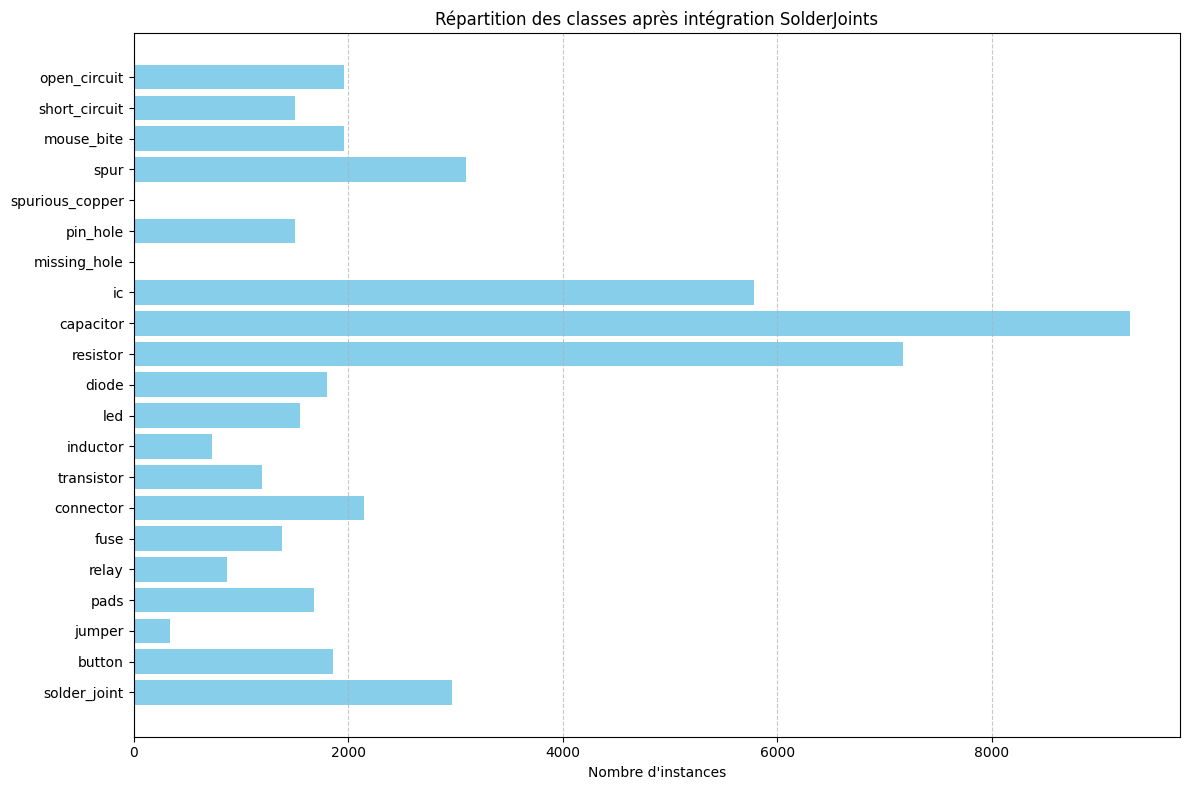

In [ ]:
print("\n--- Exécution de la réduction pour 'ic' (5%) ---")
reduce_class_instances(['ic'], 0.05)

print("\n--- Re-évaluation de la répartition des classes après réduction ---")
# To re-evaluate, we'll re-run the code for class distribution directly.
# This code was previously in cell '94cd8d2b'.

import os
import matplotlib.pyplot as plt

# Reuse count logic to get fresh numbers
labels_dir = '/content/datasets/all_pcb_yolo/labels'
images_dir = '/content/datasets/all_pcb_yolo/images' # Added images_dir for image count
base_classes = [
    'open_circuit', 'short_circuit', 'mouse_bite', 'spur', 'spurious_copper',
    'pin_hole', 'missing_hole', 'ic', 'capacitor', 'resistor', 'diode',
    'led', 'inductor', 'transistor', 'connector', 'fuse', 'relay',
    'pads', 'jumper', 'button', 'solder_joint'
]

class_counts = {i: 0 for i in range(len(base_classes))}
image_class_mapping = {}

if os.path.exists(labels_dir):
    for label_file in os.listdir(labels_dir):
        if label_file.endswith('.txt'):
            image_stem = os.path.splitext(label_file)[0]
            image_class_mapping[image_stem] = set() # Store classes present in each image
            with open(os.path.join(labels_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        # Fix: Convert to float first, then to int, to handle '7.0' properly
                        cid = int(float(parts[0]))
                        if cid in class_counts:
                            class_counts[cid] += 1
                            image_class_mapping[image_stem].add(cid)

total_instances = sum(class_counts.values())

# Count total images and label files
total_image_files = len([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
total_label_files = len([f for f in os.listdir(labels_dir) if f.lower().endswith('.txt')])

print(f"--- Répartition des classes et comptage des images ---")
print(f"Total images: {total_image_files}")
print(f"Total label files: {total_label_files}")

print(f"\n--- Ratio de répartition des classes (Total: {total_instances} instances) ---")
print(f"{'Classe':<20} | {'Instances':<10} | {'Ratio (%)'}")
print("-" * 45)

for i, name in enumerate(base_classes):
    count = class_counts[i]
    ratio = (count / total_instances * 100) if total_instances > 0 else 0
    print(f"{name:<20} | {count:<10} | {ratio:>8.2f}%")

# Alert on rare classes
rare_classes = [base_classes[i] for i, c in class_counts.items() if c < 50 and c > 0] # Only show rare classes with > 0 instances
if rare_classes:
    print(f"\nATTENTION: Les classes suivantes ont moins de 50 instances: {rare_classes}")

# Identify zero-instance classes
zero_instance_classes = [base_classes[i] for i, c in class_counts.items() if c == 0]
if zero_instance_classes:
    print(f"ATTENTION: Les classes suivantes ont 0 instances: {zero_instance_classes}")


# Prepare data for plotting
names = [base_classes[i] for i in range(len(base_classes))]
values = [class_counts[i] for i in range(len(base_classes))]

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(names, values, color='skyblue')
plt.xlabel('Nombre d\'instances')
plt.title('Répartition des classes après intégration SolderJoints')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Define the directory where unified images are stored
IMAGES_DIR = '/content/datasets/all_pcb_yolo/images'

# Define prefixes used for each dataset during unification
DATASET_PREFIXES = {
    'DeepPCB': 'DP_',
    'NewWACV': 'WACV_',
    'ElectroCom61': 'E61_',
    'KaggleDefects': 'KGD_',
    'SolderJoints': 'SOLDER_'
}

print("--- Affichage de 5 images aléatoires par dataset ---")

if not os.path.exists(IMAGES_DIR):
    print(f"Le répertoire des images unifiées '{IMAGES_DIR}' n'existe pas.")
else:
    all_image_files = list(Path(IMAGES_DIR).glob('*.*'))

    for dataset_name, prefix in DATASET_PREFIXES.items():
        print(f"\nDataset: {dataset_name} (préfixe: {prefix})")
        # Filter images by prefix - MODIFIED LINE
        dataset_images = [img_path for img_path in all_image_files if prefix in img_path.name]

        if not dataset_images:
            print(f"  Aucune image trouvée pour {dataset_name}.")
            continue

        # Select up to 5 random images
        sample_images = random.sample(dataset_images, min(len(dataset_images), 5))

        plt.figure(figsize=(20, 5))
        for i, img_path in enumerate(sample_images):
            ax = plt.subplot(1, min(len(dataset_images), 5), i + 1)
            try:
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"    Attention: Impossible de lire l'image {img_path.name}.")
                    continue
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.imshow(img_rgb)
                plt.title(f"{dataset_name}\n{img_path.name}", fontsize=10)
                plt.axis('off')
            except Exception as e:
                print(f"    Erreur lors du traitement de l'image {img_path.name}: {e}")
                plt.axis('off')
        plt.tight_layout()
        plt.show()

In [ ]:
import os

# This path was reported as the download location by kagglehub
# from the 'new-download-script' cell execution.
kaggle_defect_dataset_root = '/kaggle/input/pcb-defect-detection-dataset'

print(f"Contenu de '{kaggle_defect_dataset_root}':")
if os.path.exists(kaggle_defect_dataset_root):
    for item in os.listdir(kaggle_defect_dataset_root):
        item_path = os.path.join(kaggle_defect_dataset_root, item)
        if os.path.isdir(item_path):
            print(f"- {item}/ (dir)")
            # Optionally, list contents of subdirectories for deeper inspection
            if item == 'PKU-Market-PCB(Data enhanced version)':
                print(f"  Contenu de '{item}': {os.listdir(item_path)}")
        else:
            print(f"- {item} (file)")
else:
    print(f"Le chemin '{kaggle_defect_dataset_root}' n'existe pas. Il se peut qu'il y ait un problème avec le montage ou le téléchargement.")


Contenu de '/kaggle/input/pcb-defect-detection-dataset':
- PKU-Market-PCB(Data enhanced version)/ (dir)
  Contenu de 'PKU-Market-PCB(Data enhanced version)': ['valid', 'Class.txt', 'test', 'train']
- DeepPCB/ (dir)


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Define the directory where unified images are stored
IMAGES_DIR = '/content/datasets/all_pcb_yolo/images'

# Define prefixes used for each dataset during unification
DATASET_PREFIXES = {
    'DeepPCB': 'DP_',
    'NewWACV': 'WACV_',
    'ElectroCom61': 'E61_',
    'KaggleDefects': 'KGD_',
    'SolderJoints': 'SOLDER_'
}

print("--- Affichage des images pour les datasets KaggleDefects et les autres ---")

if not os.path.exists(IMAGES_DIR):
    print(f"Le répertoire des images unifiées '{IMAGES_DIR}' n'existe pas.")
else:
    all_image_files = list(Path(IMAGES_DIR).glob('*.*'))

    # Iterate through all prefixes to display images
    for dataset_name, prefix in DATASET_PREFIXES.items():
        print(f"\nDataset: {dataset_name} (préfixe: {prefix})")
        # Filter images by prefix
        dataset_images = [img_path for img_path in all_image_files if img_path.name.startswith(prefix)]

        if not dataset_images:
            print(f"  Aucune image trouvée pour {dataset_name}.")
            continue

        # Select up to 5 random images
        sample_images = random.sample(dataset_images, min(len(dataset_images), 5))

        plt.figure(figsize=(20, 5))
        for i, img_path in enumerate(sample_images):
            ax = plt.subplot(1, min(len(dataset_images), 5), i + 1)
            try:
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"    Attention: Impossible de lire l'image {img_path.name}.")
                    continue
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                plt.imshow(img_rgb)
                plt.title(f"{dataset_name}\n{img_path.name}", fontsize=10)
                plt.axis('off')
            except Exception as e:
                print(f"    Erreur lors du traitement de l'image {img_path.name}: {e}")
                plt.axis('off')
        plt.tight_layout()
        plt.show()

In [ ]:
import os
import torch
import shutil
import cv2
import random
from pathlib import Path
from ultralytics import YOLO
from google.colab import drive

# 0. Mount Drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/PCB_YOLO_Backups'
os.makedirs(drive_path, exist_ok=True)

# 1. Cleanup orphaned images and labels
img_dir = '/content/datasets/all_pcb_yolo/images'
lbl_dir = '/content/datasets/all_pcb_yolo/labels'

def prepare_dataset(images_dir, labels_dir):
    # Cleanup orphans: remove images without corresponding label files
    if os.path.exists(images_dir):
        images = os.listdir(images_dir)
        removed_imgs = 0
        for img_name in images:
            # Construct label filename (assuming image is e.g. 'image.jpg', label is 'image.txt')
            label_name = os.path.splitext(img_name)[0] + '.txt'
            if not os.path.exists(os.path.join(labels_dir, label_name)):
                try:
                    os.remove(os.path.join(images_dir, img_name))
                    removed_imgs += 1
                except OSError as e:
                    print(f"Erreur lors de la suppression de l'image orpheline {img_name}: {e}")
        if removed_imgs > 0: print(f'Nettoyage : {removed_imgs} images sans labels supprimées.')

    # Cleanup orphans: remove label files without corresponding image files
    if os.path.exists(labels_dir):
        labels = os.listdir(labels_dir)
        removed_lbls = 0
        for lbl_name in labels:
            # Check for common image extensions (case-insensitive)
            img_stem = os.path.splitext(lbl_name)[0]
            img_found = False
            for ext in ['.jpg', '.jpeg', '.png']:
                if os.path.exists(os.path.join(images_dir, img_stem + ext)):
                    img_found = True
                    break
            if not img_found:
                try:
                    os.remove(os.path.join(labels_dir, lbl_name))
                    removed_lbls += 1
                except OSError as e:
                    print(f"Erreur lors de la suppression du label orphelin {lbl_name}: {e}")
        if removed_lbls > 0: print(f'Nettoyage : {removed_lbls} labels sans images supprimés.')


print("--- Préparation finale du dataset (nettoyage des orphelins) ---")
prepare_dataset(img_dir, lbl_dir)
print("Nettoyage terminé.")

# 2. Training Setup with Callbacks
# Start with a fresh YOLOs model
model = YOLO('yolo11m.pt')

def on_train_epoch_end(trainer):
    current_epoch = trainer.epoch + 1
    if current_epoch % 10 == 0:
        last_pt = os.path.join(trainer.save_dir, 'weights', 'last.pt')
        if os.path.exists(last_pt):
            shutil.copy(last_pt, os.path.join(drive_path, f'epoch_{current_epoch}_last.pt'))

model.add_callback("on_train_epoch_end", on_train_epoch_end)

# Determine device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Utilisation de la carte graphique: {torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'}")

# 3. Start training
num_epochs = 100 # Increased epochs to leverage improved dataset
results = model.train(
    data='/content/datasets/all_pcb_yolo/dataset.yaml',
    epochs=num_epochs,
    imgsz=640,
    batch=16,
    device=device,
    val=True,
    save_period=5,
    optimizer='auto',
    lr0=0.01,
    lrf=0.001,
    plots=True,
    resume=True, # Resume training from last checkpoint
    workers=8, # Use more workers for data loading
    compile=True # Enable PyTorch 2.0 compilation for speedup
)

# 4. Final Export
best_local = os.path.join(model.trainer.save_dir, 'weights', 'best.pt')
if os.path.exists(best_local):
    final_target = os.path.join(drive_path, f'yolo11s_pcb_finale_{num_epochs}epochs.pt')
    shutil.copy(best_local, final_target)
    print(f'\n✅ Modèle final exporté : {final_target}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Préparation finale du dataset (nettoyage des orphelins) ---
Nettoyage terminé.
Utilisation de la carte graphique: Tesla T4
WARNING ⚠️ model 'yolo11m.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/all_pcb_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=

In [ ]:
from IPython.display import Image, display
import os

runs_dir = 'runs/detect'
if os.path.exists(runs_dir):
    latest_run = sorted([d for d in os.listdir(runs_dir) if d.startswith('train')])[-1]
    # YOLO génère plusieurs batchs de validation, on regarde le premier
    mosaic_path = os.path.join(runs_dir, latest_run, 'val_batch0_pred.jpg')

    if os.path.exists(mosaic_path):
        print(f"Mosaïque de prédictions sur le batch de validation (Run: {latest_run}) :")
        display(Image(filename=mosaic_path, width=1000))
    else:
        print("La mosaïque de prédiction sera générée après la première validation (toutes les 5 époques selon votre config).")

In [ ]:
import pandas as pd
import os

# Trouver le dernier dossier d'entraînement
runs_dir = 'runs/detect'
if os.path.exists(runs_dir):
    latest_run = sorted([d for d in os.listdir(runs_dir) if d.startswith('train')])[-1]
    results_csv = os.path.join(runs_dir, latest_run, 'results.csv')

    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        # Nettoyer les noms de colonnes (parfois des espaces traînent)
        df.columns = [c.strip() for c in df.columns]
        print(f"Dernières métriques (Run: {latest_run}) :")
        display(df.tail(5))
    else:
        print("Le fichier results.csv n'est pas encore généré.")

In [ ]:
from IPython.display import Image, display
import os

runs_dir = 'runs/detect'
if os.path.exists(runs_dir):
    latest_run = sorted([d for d in os.listdir(runs_dir) if d.startswith('train')])[-1]
    results_png = os.path.join(runs_dir, latest_run, 'results.png')

    if os.path.exists(results_png):
        print(f"Courbes d'apprentissage (Run: {latest_run}) :")
        display(Image(filename=results_png, width=800))
    else:
        print("Le graphique results.png sera généré après la première époque.")

In [ ]:
# Re-install PyTorch with CUDA support
# This command installs PyTorch compatible with CUDA 11.8, a commonly supported version in Colab.
# If you encounter further issues, you might need to adjust the CUDA version (e.g., cu121).
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import torch
from ultralytics import YOLO
import os

# Set the number of threads for CPU operations, attempting to use 4 cores
torch.set_num_threads(4)
print(f"PyTorch will use {torch.get_num_threads()} CPU threads for operations.")

# Check CUDA availability
if torch.cuda.is_available():
    print(f"CUDA est disponible. GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA n'est PAS disponible. L'entraînement se fera sur CPU.")

# The actual training logic will be handled in the dedicated training cell (e.g., 69f8b387).

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import os

runs_dir = 'runs/detect'
latest_run_dir = None

if os.path.exists(runs_dir):
    all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
    if all_runs:
        # Find the latest run directory based on naming convention (e.g., train, train1, train2...)
        latest_run_dir = sorted(all_runs, key=lambda x: int(x[len('train'):]) if x.startswith('train') and x[len('train'):].isdigit() else (0 if x == 'train' else float('inf')))[-1]
        latest_run_dir = os.path.join(runs_dir, latest_run_dir)

if latest_run_dir:
    # Try to find common log files generated by Ultralytics
    log_file_path = os.path.join(latest_run_dir, 'results.csv') # Ultralytics typically saves metrics in results.csv

    if not os.path.exists(log_file_path):
        log_file_path = os.path.join(latest_run_dir, 'results.txt') # Fallback to results.txt if csv not found

    if os.path.exists(log_file_path):
        print(f"Affichage du journal de progression pour : {latest_run_dir}")
        with open(log_file_path, 'r') as f:
            print(f.read())
    else:
        print(f"Aucun fichier de journal (results.csv ou results.txt) trouvé dans '{latest_run_dir}'.")
        print("L'entraînement pourrait être en cours ou n'a pas encore généré de fichier de logs.")
else:
    print("Aucun répertoire d'entraînement trouvé dans 'runs/detect/'.")

Affichage du journal de progression pour : runs/detect/train
epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
1,252.42,1.49006,4.22904,1.34712,0.53611,0.45615,0.47089,0.30086,1.34556,2.59755,1.11057,3.99388e-05,3.99388e-05,3.99388e-05
2,447.385,1.39132,2.13483,1.27424,0.74373,0.62955,0.67169,0.42778,1.23854,1.92147,1.04134,7.83417e-05,7.83417e-05,7.83417e-05
3,650.674,1.37214,1.65604,1.25594,0.78965,0.68324,0.71343,0.44946,1.19189,1.87565,1.00627,0.000115146,0.000115146,0.000115146
4,850.599,1.32714,1.40286,1.24514,0.84663,0.70829,0.7371,0.47779,1.19838,1.68938,1.01448,0.000112807,0.000112807,0.000112807
5,1048.32,1.29602,1.26163,1.22007,0.82536,0.72641,0.75108,0.48444,1.14984,1.72854,0.9881,0.00011041,0.00011041,0.00011041
6,1247.37,1.28033,1.17017,1.21587,0.74027,0.73668,0.7556,0.50049,1.16645,1.6624,0.98314,0.000108012,0.000108012,0.000108012

Ce script recherche le dossier de la dernière exécution d'entraînement YOLO (`runs/detect/trainX`) et tente d'afficher le contenu du fichier `results.csv` ou `results.txt` s'il est trouvé. Ce fichier contient généralement des métriques telles que la perte d'entraînement, la perte de validation, le mAP (mean Average Precision) et d'autres indicateurs de performance pour chaque époque.

Si l'entraînement vient de commencer ou n'a pas encore écrit ce fichier, il est possible que rien ne s'affiche ou que le fichier soit vide.

Affichage des résultats d'entraînement pour : runs/detect/train


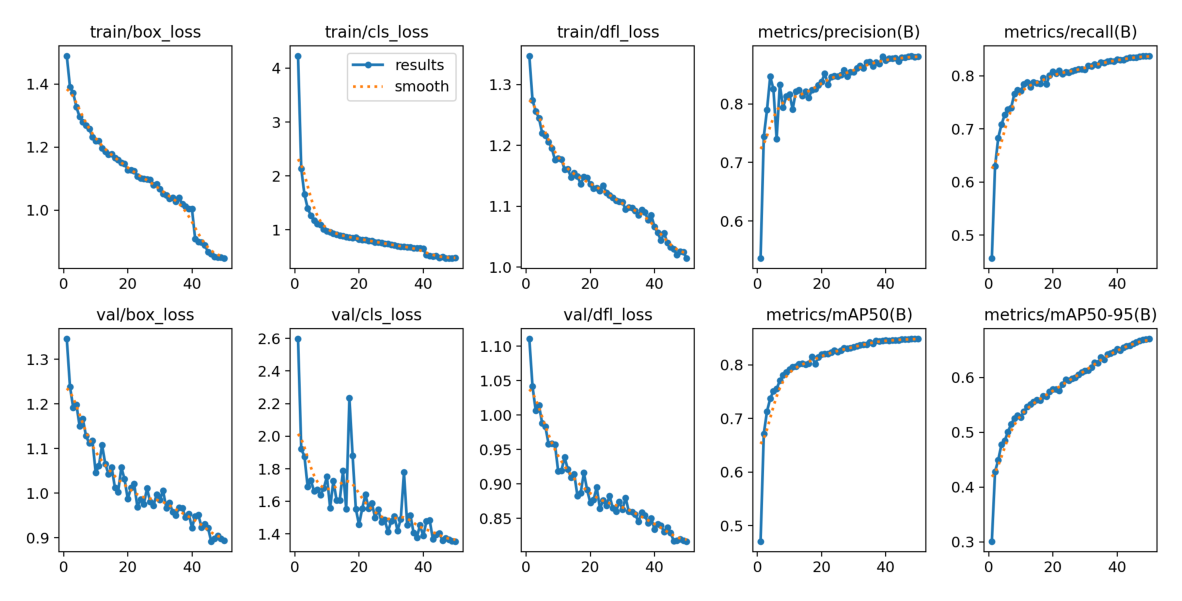

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Chemin vers les résultats du dernier entraînement
# Note: YOLOv8 crée généralement des dossiers avec un suffixe incrémental (ex: train, train2, train3, etc.)
# Nous allons essayer de trouver le dernier dossier de résultats.

runs_dir = 'runs/detect'
latest_run_dir = None
if os.path.exists(runs_dir):
    all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
    # Trie les dossiers pour trouver le plus récent (ex: train3 est plus récent que train2)
    if all_runs:
        # On utilise une fonction de tri personnalisée pour gérer 'train', 'train1', 'train2'...
        # Le tri par défaut des chaînes peut donner 'train10' avant 'train2', donc un tri numérique est préférable si possible.
        # Pour simplifier, nous allons prendre le dossier avec le nom le plus 'grand' (souvent le plus récent)
        latest_run_dir = sorted(all_runs, key=lambda x: int(x[len('train'):]) if x.startswith('train') and x[len('train'):].isdigit() else (0 if x == 'train' else float('inf')))[-1]
        latest_run_dir = os.path.join(runs_dir, latest_run_dir)

if latest_run_dir:
    results_path = os.path.join(latest_run_dir, 'results.png')
    if os.path.exists(results_path):
        print(f"Affichage des résultats d'entraînement pour : {latest_run_dir}")
        img = mpimg.imread(results_path)
        plt.figure(figsize=(15, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    else:
        print(f"Le fichier de résultats '{results_path}' n'est pas encore disponible ou n'a pas été trouvé.")
        print("Veuillez patienter pendant l'entraînement ou vérifier le dossier 'runs/detect/' pour les logs.")
else:
    print("Aucun répertoire d'entraînement trouvé dans 'runs/detect/'.")

In [ ]:
import os
import shutil
from google.colab import drive

# Monte Google Drive si ce n'est pas déjà fait
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- CONFIGURATION DU CHEMIN DE SAUVEGARDE SUR GOOGLE DRIVE ---
# REMPLACEZ CE CHEMIN PAR LE DOSSIER OÙ VOUS VOULEZ SAUVEGARDER LES MODÈLES
# Par exemple: '/content/drive/MyDrive/YOLO_Saved_Models'
google_drive_save_path = '/content/drive/MyDrive/YOLO_Models_Backup'

os.makedirs(google_drive_save_path, exist_ok=True)
print(f"Le dossier de sauvegarde sur Google Drive est : {google_drive_save_path}")

runs_dir = 'runs/detect'
latest_run_dir = None

# Trouve le répertoire de la dernière exécution d'entraînement
if os.path.exists(runs_dir):
    all_runs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]
    if all_runs:
        # Trie les dossiers pour trouver le plus récent (ex: train3 est plus récent que train2)
        latest_run_dir = sorted(all_runs, key=lambda x: int(x[len('train'):]) if x.startswith('train') and x[len('train'):].isdigit() else (0 if x == 'train' else float('inf')))[-1]
        latest_run_dir = os.path.join(runs_dir, latest_run_dir)

if latest_run_dir:
    weights_dir = os.path.join(latest_run_dir, 'weights')
    if os.path.exists(weights_dir):
        # Copie best.pt
        best_model_path = os.path.join(weights_dir, 'best.pt')
        if os.path.exists(best_model_path):
            destination_best_path = os.path.join(google_drive_save_path, f'{os.path.basename(latest_run_dir)}_best.pt')
            shutil.copy(best_model_path, destination_best_path)
            print(f"'best.pt' copié vers : {destination_best_path}")
        else:
            print(f"Le fichier 'best.pt' n'a pas été trouvé dans '{weights_dir}'.")

        # Copie last.pt
        last_model_path = os.path.join(weights_dir, 'last.pt')
        if os.path.exists(last_model_path):
            destination_last_path = os.path.join(google_drive_save_path, f'{os.path.basename(latest_run_dir)}_last.pt')
            shutil.copy(last_model_path, destination_last_path)
            print(f"'last.pt' copié vers : {destination_last_path}")
        else:
            print(f"Le fichier 'last.pt' n'a pas été trouvé dans '{weights_dir}'.")
    else:
        print(f"Le dossier 'weights' n'a pas été trouvé dans '{latest_run_dir}'. L'entraînement n'a peut-être pas encore produit de poids de modèle.")
else:
    print("Aucun répertoire d'entraînement trouvé dans 'runs/detect/'. Assurez-vous que l'entraînement a été lancé au moins une fois.")

Le dossier de sauvegarde sur Google Drive est : /content/drive/MyDrive/YOLO_Models_Backup
'best.pt' copié vers : /content/drive/MyDrive/YOLO_Models_Backup/train_best.pt
'last.pt' copié vers : /content/drive/MyDrive/YOLO_Models_Backup/train_last.pt


Ce script va d'abord monter votre Google Drive, puis chercher le dossier de la dernière exécution d'entraînement (`runs/detect/trainX/`). Il copiera ensuite les fichiers `best.pt` et `last.pt` trouvés dans le sous-dossier `weights/` vers le chemin spécifié sur votre Google Drive. Le nom des fichiers copiés inclura le nom du dossier d'entraînement (par exemple, `train_best.pt`, `train1_last.pt`) pour une meilleure organisation.

Ce script va d'abord tenter de trouver le dernier dossier d'entraînement local et d'utiliser le fichier `last.pt` qui s'y trouve pour reprendre l'entraînement. Si vous souhaitez reprendre à partir d'un fichier spécifique (par exemple, un `best.pt` ou un fichier sur Google Drive), vous devrez commenter la section de recherche automatique et décommenter/modifier la ligne `resume_path` en conséquence.

Assurez-vous que votre Google Drive est monté si vous reprenez un modèle qui y est stocké.

# Task
Modify the content of the `unify_all_to_yolo_v2.py` script in cell `6eef32f6` to ensure that the `get_global_class_id` function strictly maps to `BASE_CLASSES`, explicitly drops unmapped annotations, and enhance `CLASS_MAPPING_TO_TARGET` and heuristics to better categorize specific component names into the 21 fixed `BASE_CLASSES`. Then, save and execute the modified script to unify the datasets with the fixed class taxonomy.

## Modify unification script for fixed taxonomy

### Subtask:
Modify the `unify_all_to_yolo_v2.py` script content in cell `6eef32f6`. Update the `get_global_class_id` function to strictly map to `BASE_CLASSES` and explicitly drop unmapped annotations. Enhance `CLASS_MAPPING_TO_TARGET` and heuristics to better categorize specific component names from source datasets into the fixed 21 `BASE_CLASSES`.


**Reasoning**:
The previous step updated the `unify_all_to_yolo_v2.py` script. Now, I need to execute this script to unify the datasets with the fixed class taxonomy as per the subtask instructions.

